### Time-based train/test split
Since we're predicting future behavior, a random split would let the model 
train on customers who purchased later than some test customers — leaking 
timeline information that wouldn't exist at real prediction time. Splitting 
by first purchase date instead: train on earlier customers, test on later ones.

In [2]:
import pandas as pd
import numpy as np

model_data = pd.read_csv("../data/processed/model_ready.csv")
model_data["first_purchase_date"] = pd.to_datetime(model_data["first_purchase_date"])

# Sort chronologically — this is the whole point of a time-based split
model_data = model_data.sort_values("first_purchase_date").reset_index(drop=True)

print(f"Date range: {model_data['first_purchase_date'].min().date()} to {model_data['first_purchase_date'].max().date()}")
print(f"Total customers: {len(model_data):,}")

Date range: 2016-10-03 to 2018-03-02
Total customers: 55,904


### Choosing the split point
Using an 80/20 split by date rather than by row count, so the split reflects 
a real point in time — everyone before it is "history," everyone after is 
"the future" from the model's perspective.

In [3]:
split_date = model_data["first_purchase_date"].quantile(0.8)
print(f"Split date: {split_date.date()}")

train_df = model_data[model_data["first_purchase_date"] < split_date].copy()
test_df = model_data[model_data["first_purchase_date"] >= split_date].copy()

print(f"\nTrain: {len(train_df):,} customers ({train_df['first_purchase_date'].min().date()} to {train_df['first_purchase_date'].max().date()})")
print(f"Test:  {len(test_df):,} customers ({test_df['first_purchase_date'].min().date()} to {test_df['first_purchase_date'].max().date()})")

print(f"\nTrain target rate: {train_df['made_second_purchase'].mean():.2%}")
print(f"Test target rate:  {test_df['made_second_purchase'].mean():.2%}")

Split date: 2018-01-11

Train: 44,723 customers (2016-10-03 to 2018-01-11)
Test:  11,181 customers (2018-01-11 to 2018-03-02)

Train target rate: 4.09%
Test target rate:  3.51%


### Separate features from target, drop non-feature columns
customer_unique_id and first_purchase_date aren't features — they're 
identifiers, not signal for the model to learn from.

In [4]:
drop_cols = ["customer_unique_id", "first_purchase_date", "made_second_purchase"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["made_second_purchase"]

X_test = test_df.drop(columns=drop_cols)
y_test = test_df["made_second_purchase"]

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

# Save split for reuse in later notebooks
train_df.to_csv("../data/processed/train.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

X_train: (44723, 40), y_train: (44723,)
X_test:  (11181, 40), y_test:  (11181,)


In [5]:
X_train.head()

,n_items,n_distinct_products,items_total_price,total_freight,payment_total,max_installments,delivery_days,delivery_delay_days,review_score,has_review,...,state_RJ,state_RN,state_RO,state_RR,state_RS,state_SC,state_SE,state_SP,state_TO,category_frequency
0,1,1,29.90,15.56,45.46,1.0,23.0,-1.0,4.0,1,...,False,False,False,False,False,False,False,True,False,0.047242
1,1,1,21.90,17.19,39.09,1.0,24.0,-11.0,4.0,1,...,False,False,False,False,True,False,False,False,False,0.081157
2,1,1,36.49,17.24,53.73,1.0,31.0,-26.0,3.0,1,...,False,False,False,False,True,False,False,False,False,0.081157
3,1,1,119.90,13.56,133.46,6.0,28.0,-23.0,1.0,1,...,False,False,False,False,False,False,False,True,False,0.067008
4,1,1,29.99,10.96,40.95,4.0,11.0,-40.0,5.0,1,...,False,False,False,False,False,False,False,True,False,0.003220


In [6]:
X_test.head()

,n_items,n_distinct_products,items_total_price,total_freight,payment_total,max_installments,delivery_days,delivery_delay_days,review_score,has_review,...,state_RJ,state_RN,state_RO,state_RR,state_RS,state_SC,state_SE,state_SP,state_TO,category_frequency
44723,1,1,157.77,9.30,167.07,1.0,12.0,-7.0,1.0,1,...,False,False,False,False,False,False,False,True,False,0.018263
44724,1,1,69.90,16.25,86.15,3.0,19.0,-10.0,5.0,1,...,False,False,False,False,False,False,False,False,False,0.025258
44725,1,1,13.90,15.10,29.00,1.0,12.0,-34.0,5.0,1,...,True,False,False,False,False,False,False,False,False,0.096558
44726,1,1,199.99,51.27,251.26,5.0,18.0,-16.0,4.0,1,...,False,False,False,False,False,False,False,False,False,0.041339
44727,1,1,29.99,15.10,45.09,1.0,8.0,-18.0,5.0,1,...,False,False,False,False,False,True,False,False,False,0.020571


In [7]:
train_df["first_purchase_date"].head()

0   2016-10-03 09:44:50
1   2016-10-03 16:56:50
2   2016-10-03 21:13:36
3   2016-10-03 22:06:03
4   2016-10-03 22:31:31
Name: first_purchase_date, dtype: datetime64[us]

### Baseline model — logistic regression
Starting simple and interpretable before anything more complex. With a ~4% 
positive rate, class_weight="balanced" is needed so the model doesn't just 
learn to predict "no" for everyone and call it a win.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)
import matplotlib.pyplot as plt

# Logistic regression is sensitive to feature scale — standardize numeric columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# balanced class_weight adjusts for the ~4% positive rate automatically —
# it upweights the minority class rather than us manually resampling
log_reg = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average Precision (PR-AUC): {average_precision_score(y_test, y_proba):.4f}")

              precision    recall  f1-score   support

           0       0.97      0.66      0.78     10788
           1       0.04      0.42      0.08       393

    accuracy                           0.65     11181
   macro avg       0.51      0.54      0.43     11181
weighted avg       0.94      0.65      0.76     11181

ROC-AUC: 0.5658
Average Precision (PR-AUC): 0.0479


### ROC and Precision-Recall curves
With such an imbalanced target, PR-AUC is actually more informative than 
ROC-AUC — ROC can look deceptively good even when the model isn't finding 
many of the true positives.

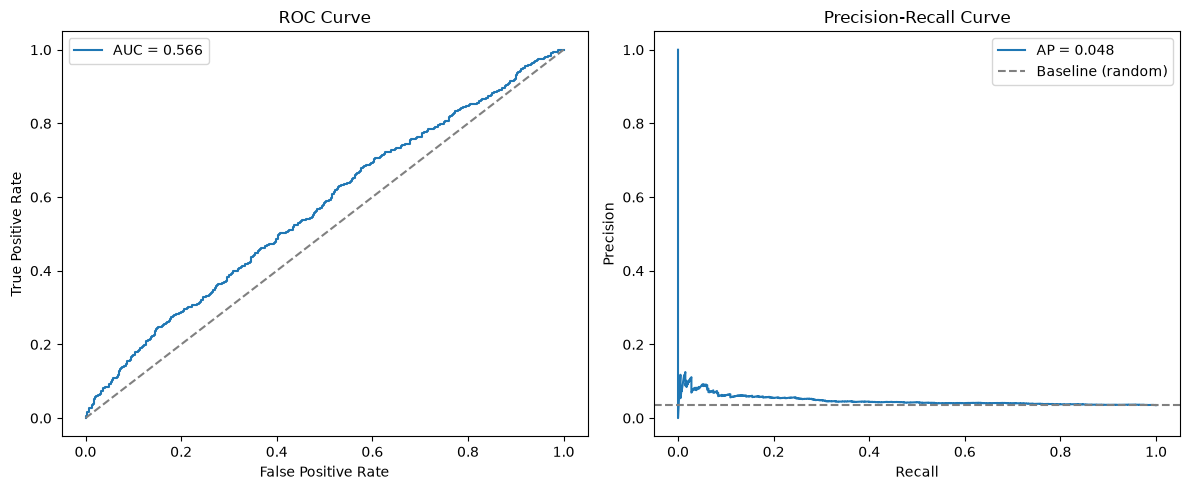

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[1].plot(recall, precision, label=f"AP = {average_precision_score(y_test, y_proba):.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label="Baseline (random)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/baseline_model_curves.png", dpi=150)
plt.show()

### Checking which features the baseline is relying on
Before assuming the weak result means "no signal exists," checking the model's 
coefficients — a badly performing model can still reveal whether any individual 
feature is pulling weight.

In [10]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": log_reg.coef_[0]
}).sort_values("coefficient", key=abs, ascending=False)

print(coef_df.head(15))

                feature  coefficient
33             state_RR    -0.684381
37             state_SP    -0.299484
22             state_MG    -0.238816
5      max_installments     0.217275
30             state_RJ    -0.211097
17             state_CE    -0.173636
34             state_RS    -0.173362
29             state_PR    -0.163378
4         payment_total    -0.162940
35             state_SC    -0.160362
39   category_frequency     0.151023
16             state_BA    -0.144588
18             state_DF    -0.120567
7   delivery_delay_days    -0.119251
21             state_MA    -0.109631


### Sanity-checking the top coefficient
state_RR has an unusually large coefficient — checking whether that's a real 
signal or just a symptom of very few customers from that state, which would 
make the coefficient unstable and untrustworthy.

In [13]:

print(f"RR customers in training set: {X_train['state_RR'].sum()}")
print(f"RR customers in test set: {X_test['state_RR'].sum()}")

RR customers in training set: 19
RR customers in test set: 5


### Gradient boosting model
Logistic regression assumes linear relationships — it can't naturally capture 
interactions like "delivery delay only hurts retention when the review score is 
also low." XGBoost handles non-linear patterns and feature interactions without 
needing them specified manually, which is a fairer test of how predictable this 
problem actually is.

In [ ]:



from xgboost import XGBClassifier

# scale_pos_weight handles class imbalance for XGBoost specifically —
# it's the ratio of negative to positive examples, telling the model
# how much more to "care" about getting the rare positive class right
neg, pos = y_train.value_counts()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,           
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",  
    random_state=42,
)

xgb_model.fit(X_train, y_train) 




scale_pos_weight: 23.47
              precision    recall  f1-score   support

           0       0.97      0.72      0.82     10788
           1       0.05      0.38      0.08       393

    accuracy                           0.71     11181
   macro avg       0.51      0.55      0.45     11181
weighted avg       0.94      0.71      0.80     11181

ROC-AUC: 0.5727
Average Precision (PR-AUC): 0.0468


In [16]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print(f"Average Precision (PR-AUC): {average_precision_score(y_test, y_proba_xgb):.4f}")


              precision    recall  f1-score   support

           0       0.97      0.72      0.82     10788
           1       0.05      0.38      0.08       393

    accuracy                           0.71     11181
   macro avg       0.51      0.55      0.45     11181
weighted avg       0.94      0.71      0.80     11181

ROC-AUC: 0.5727
Average Precision (PR-AUC): 0.0468


### Comparing to the baseline
Plotting both models' PR curves together — the metric that matters most given 
how imbalanced the target is.

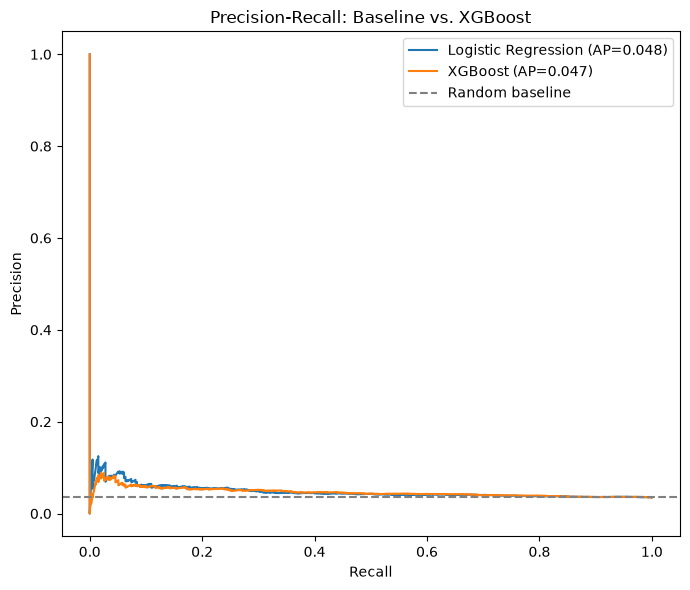

In [17]:
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_proba)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_proba_xgb)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_lr, precision_lr, label=f"Logistic Regression (AP={average_precision_score(y_test, y_proba):.3f})")
ax.plot(recall_xgb, precision_xgb, label=f"XGBoost (AP={average_precision_score(y_test, y_proba_xgb):.3f})")
ax.axhline(y_test.mean(), linestyle="--", color="gray", label="Random baseline")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall: Baseline vs. XGBoost")
ax.legend()
plt.tight_layout()
plt.savefig("../data/processed/model_comparison_pr_curve.png", dpi=150)
plt.show()

### Feature importance check
Before accepting the performance ceiling as final, checking which features 
XGBoost actually found useful — this also serves as a second sanity check 
against the same small-sample instability we caught in the baseline model.

In [18]:
importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df.head(15))

                feature  importance
8          review_score    0.045447
39   category_frequency    0.045014
5      max_installments    0.043656
38             state_TO    0.040407
2     items_total_price    0.037227
29             state_PR    0.036917
18             state_DF    0.036819
4         payment_total    0.033280
1   n_distinct_products    0.032432
12      payment_voucher    0.032332
22             state_MG    0.031380
27             state_PE    0.028402
26             state_PB    0.028113
7   delivery_delay_days    0.027959
34             state_RS    0.027479


### Checking state_TO sample size
Another low-population state near the top of feature importance — checking 
whether this is a real pattern or the same small-sample instability seen 
with state_RR in the baseline model.

In [19]:
print(f"TO customers in training set: {X_train['state_TO'].sum()}")

TO customers in training set: 135
